Ridge Regression is a type of linear regression that uses L2 regularization to penalize large coefficients. It is used to handle multicollinearity, reduce overfitting, and stabilize coefficient estimates by shrinking them, without eliminating any features from the model."


Ridge Regression is a type of linear regression with L2 regularization.
    Standard linear regression tries to minimize the sum of squared errors (SSE):
      SSE=i∑ (yi −y^ i )2
    Ridge adds a penalty term proportional to the square of the coefficients:
      Loss=i∑ (yi −y^ i )2+λj∑ βj2

2. When to use Ridge Regression

    Multicollinearity in features

    When features are highly correlated, ordinary linear regression coefficients become unstable. Ridge stabilizes them by penalizing large coefficients.

    High-dimensional datasets (p > n)

    If you have more features than observations, Ridge can still produce a solution because it avoids overfitting via regularization.

    Continuous target variable

    Ridge is for regression tasks, not classification (for that, consider logistic regression with L2 regularization).

    You want all features to contribute

    Unlike Lasso, Ridge keeps all features; it just shrinks them. Useful when you believe every variable carries some signal.


    3. Benefits of Ridge Regression

            Reduces overfitting

            By penalizing large coefficients, Ridge reduces variance in your model.

            Handles multicollinearity

            Makes coefficient estimates more reliable.

            Stable and numerically robust

            Works well with high-dimensional or correlated datasets.

            Closed-form solution
            β^ =(XTX+λI)−1XTy


4. Key points for interviews

    Difference between Ridge and Lasso:

    Ridge = L2 regularization (shrinks, doesn’t remove features)

    Lasso = L1 regularization (can shrink some coefficients to 0, effectively doing feature selection)

    Choice of λ (hyperparameter):

    Small λ → closer to OLS regression

    Large λ → more shrinkage, simpler model

    Often used with standardized features because penalty depends on the magnitude of coefficients.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error

data=load_diabetes()

print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [11]:
#dependent and independent
X=data.data
y=data.target


X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=45)

#craete model
model=LinearRegression()

# train regression
model.fit(X_train,y_train)
print(model.coef_)
print(model.intercept_)

#predict output
y_pred=model.predict(X_test)

[  23.45465406 -247.42747406  492.1087518   329.35876431 -970.79723039
  573.54295519  182.42162368  255.92168168  794.21609282   89.32249214]
152.13623331746496


In [13]:


print("R2 score",r2_score(y_test,y_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))

R2 score 0.5188113124539249
RMSE 48.72713760953252


### Apply Ridge Regression

In [17]:
from sklearn.linear_model import Ridge

#create ridge transform.
Ridge_algo=Ridge(alpha=100000)

#train data
Ridge_algo.fit(X_train,y_train)

# metric
print(Ridge_algo.coef_)
print(Ridge_algo.intercept_)


#predict
y_pred1=Ridge_algo.predict(X_test)

[ 0.00260126  0.00057066  0.00776597  0.0060976   0.00233864  0.00184724
 -0.00513942  0.0052716   0.00734598  0.00528629]
151.83287930791352


In [18]:
print("R2 score",r2_score(y_test,y_pred1))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred1)))

R2 score -0.00042490200441935855
RMSE 70.25956272917782


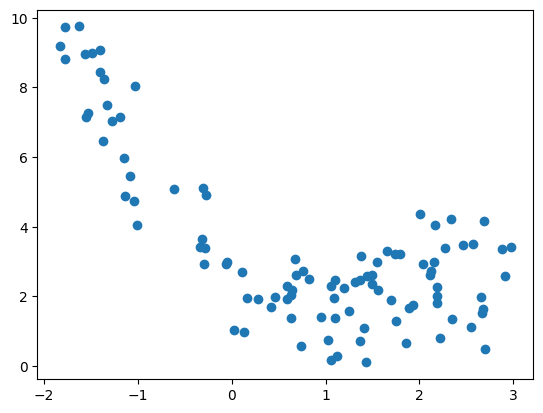

In [ ]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()




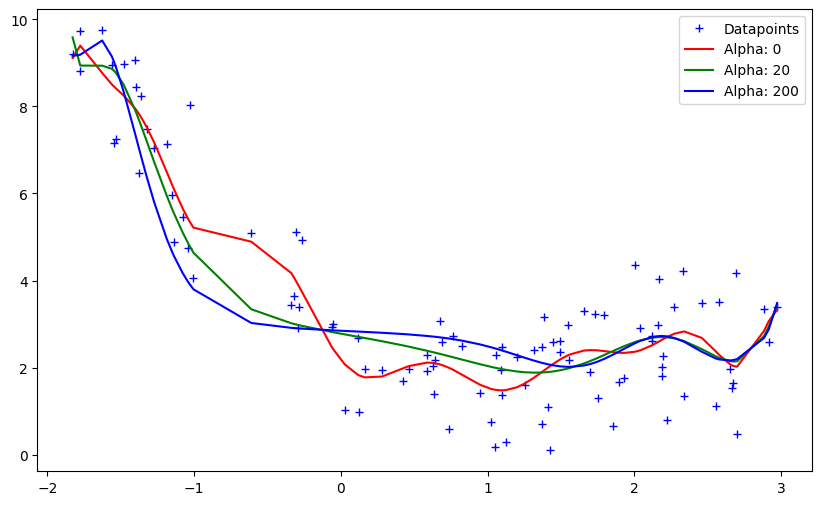

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    #train data
    model.fit(x1, x2)
    #predict data
    return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()